# Tool binding

Tool binding is the step where you register tools with a LLM so that : 
- The LLM knows what tools are aavailable
- It knows what each tool does
- It knows what input format ot use

In [10]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

In [11]:
import requests

@tool
def multiply(a : int, b : int) -> int:
    """Given 2 number, return their product"""
    return a * b

    
print(multiply.invoke({'a': 4, 'b' : 3}))

12


In [12]:
multiply.name

'multiply'

In [13]:
# Tool Binding
modelWithTools = model.bind_tools([multiply])

Not all the LLMs are able to bind tools with it

# Tool Calling

Tool calling is the process where the LLM decides during the covnersation or task, that is needs to use a specific tool(function) - and generatios a structred output with
- The name of the tool
- the arguments to call it with

The LLM does not actually run the tool - it just  suggests the tool and the input arguments, The actual execution is handled by Langchain or you

In [14]:
modelWithTools.invoke('Hi how are you')

AIMessage(content="Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you with any questions or tasks you have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 211, 'total_tokens': 252}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e596b-3d83-75c3-921e-4f5d9b4462c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 211, 'output_tokens': 41, 'total_tokens': 252})

In [17]:
result = modelWithTools.invoke('Can you multiply 3 with 7').tool_calls[0]

As you can see it didnt answer, it just suggested to use a tool

# Tool execution

Tool execution is the step where the actual python fun tion(tool) is run using the input argumens that the LLM suggested during tool calling


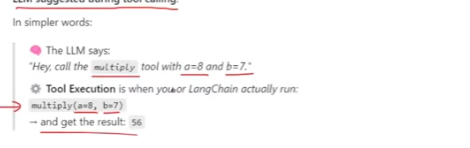

In [19]:
result

{'name': 'multiply',
 'args': {'a': 3, 'b': 7},
 'id': 'call_2u9btziptihhqjwp6cjsdr67',
 'type': 'tool_call'}

In [24]:
result['args']

{'a': 3, 'b': 7}

In [25]:
multiply.invoke(result['args'])

21

In [27]:
multiply.invoke(result)

ToolMessage(content='21', name='multiply', tool_call_id='call_2u9btziptihhqjwp6cjsdr67')

You can see above there is ToolMessage

In [42]:
query = HumanMessage('can you multiply 17 with 4')

In [43]:
message = [query]
message

[HumanMessage(content='can you multiply 17 with 4', additional_kwargs={}, response_metadata={})]

In [44]:
result = modelWithTools.invoke(message)

In [45]:
message.append(result)

In [46]:
message

[HumanMessage(content='can you multiply 17 with 4', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a":17,"b":4}', 'name': 'multiply', 'description': None}, 'id': 'call_5lzffkpgzml50s6z7g5s8qpi', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 216, 'total_tokens': 242}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e5978-beb1-7c90-a607-099a3393adb9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 17, 'b': 4}, 'id': 'call_5lzffkpgzml50s6z7g5s8qpi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 216, 'output_tokens': 26, 'total_tokens': 242})]

In [47]:
toolResult = multiply.invoke(result.tool_calls[0])

In [48]:
message.append(toolResult)

In [49]:
message

[HumanMessage(content='can you multiply 17 with 4', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a":17,"b":4}', 'name': 'multiply', 'description': None}, 'id': 'call_5lzffkpgzml50s6z7g5s8qpi', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 216, 'total_tokens': 242}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e5978-beb1-7c90-a607-099a3393adb9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 17, 'b': 4}, 'id': 'call_5lzffkpgzml50s6z7g5s8qpi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 216, 'output_tokens': 26, 'total_tokens': 242}),
 ToolMessage(content='68', name='multiply', tool_call_id='call_5lzffkpgzml50s6z7g5s8qpi')]

In [50]:
modelWithTools.invoke(message).content

'The product of 17 multiplied by 4 is 68.'